# **CIFAR-10 Image Classification using ResNet50**
This project implements image classification on the CIFAR-10 dataset, which contains 60,000 color images (32×32 pixels) across 10 classes including airplanes, automobiles, birds, cats, and more. Using transfer learning with ResNet50, a pre-trained convolutional neural network, we build a classifier that leverages features learned from ImageNet to achieve strong performance on CIFAR-10.

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
# Load the CIFAR-10 dataset
print("\nLoading CIFAR-10 dataset...")
(train_images_full, train_labels_full), (test_images, test_labels) = keras.datasets.cifar10.load_data()


Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


## **EXPLORATORY DATA ANALYSIS (EDA)**

In [3]:
# Class names for reference
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print(f"\n Dataset Overview:")
print(f"   Training images: {train_images_full.shape}")
print(f"   Training labels: {train_labels_full.shape}")
print(f"   Test images: {test_images.shape}")
print(f"   Test labels: {test_labels.shape}")
print(f"   Image dimensions: {train_images_full.shape[1:3]}")
print(f"   Color channels: {train_images_full.shape[3]}")
print(f"   Number of classes: {len(class_names)}")


 Dataset Overview:
   Training images: (50000, 32, 32, 3)
   Training labels: (50000, 1)
   Test images: (10000, 32, 32, 3)
   Test labels: (10000, 1)
   Image dimensions: (32, 32)
   Color channels: 3
   Number of classes: 10



 Visualizing sample images from each class...


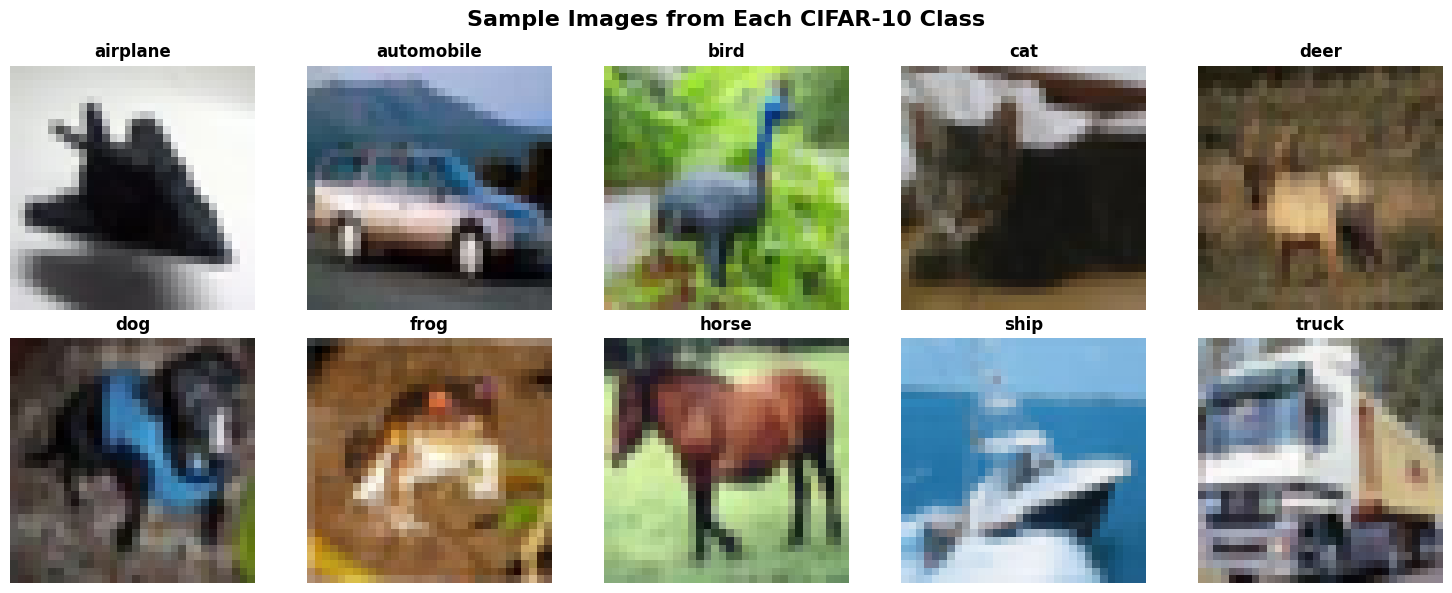

In [4]:
# Display sample images from each class
print("\n Visualizing sample images from each class...")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Each CIFAR-10 Class', fontsize=16, fontweight='bold')

for idx, class_name in enumerate(class_names):
    # Find first occurrence of this class
    class_idx = np.where(train_labels_full == idx)[0][0]
    ax = axes[idx // 5, idx % 5]
    ax.imshow(train_images_full[class_idx])
    ax.set_title(class_name, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_1_class_samples.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Count occurrences of each class
train_class_counts = Counter(train_labels_full.flatten())
test_class_counts = Counter(test_labels.flatten())

In [6]:
# Print the counts to verify data
print(f"   Training set counts: {dict(train_class_counts)}")
print(f"   Test set counts: {dict(test_class_counts)}")


   Training set counts: {np.uint8(6): 5000, np.uint8(9): 5000, np.uint8(4): 5000, np.uint8(1): 5000, np.uint8(2): 5000, np.uint8(7): 5000, np.uint8(8): 5000, np.uint8(3): 5000, np.uint8(5): 5000, np.uint8(0): 5000}
   Test set counts: {np.uint8(3): 1000, np.uint8(8): 1000, np.uint8(0): 1000, np.uint8(6): 1000, np.uint8(1): 1000, np.uint8(9): 1000, np.uint8(5): 1000, np.uint8(7): 1000, np.uint8(4): 1000, np.uint8(2): 1000}



 Analyzing class distribution...
   train_labels_full shape: (50000, 1)
   train_labels_full dtype: uint8
   First 10 labels: [6 9 9 4 1 1 2 7 8 3]
   Training set counts: {np.uint8(6): 5000, np.uint8(9): 5000, np.uint8(4): 5000, np.uint8(1): 5000, np.uint8(2): 5000, np.uint8(7): 5000, np.uint8(8): 5000, np.uint8(3): 5000, np.uint8(5): 5000, np.uint8(0): 5000}
   Test set counts: {np.uint8(3): 1000, np.uint8(8): 1000, np.uint8(0): 1000, np.uint8(6): 1000, np.uint8(1): 1000, np.uint8(9): 1000, np.uint8(5): 1000, np.uint8(7): 1000, np.uint8(4): 1000, np.uint8(2): 1000}
   Plotting training counts: [5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]
   Plotting test counts: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]

   Creating figure...
   Figure created: Figure(1400x500)
   Axes created: [<Axes: >, <Axes: >]


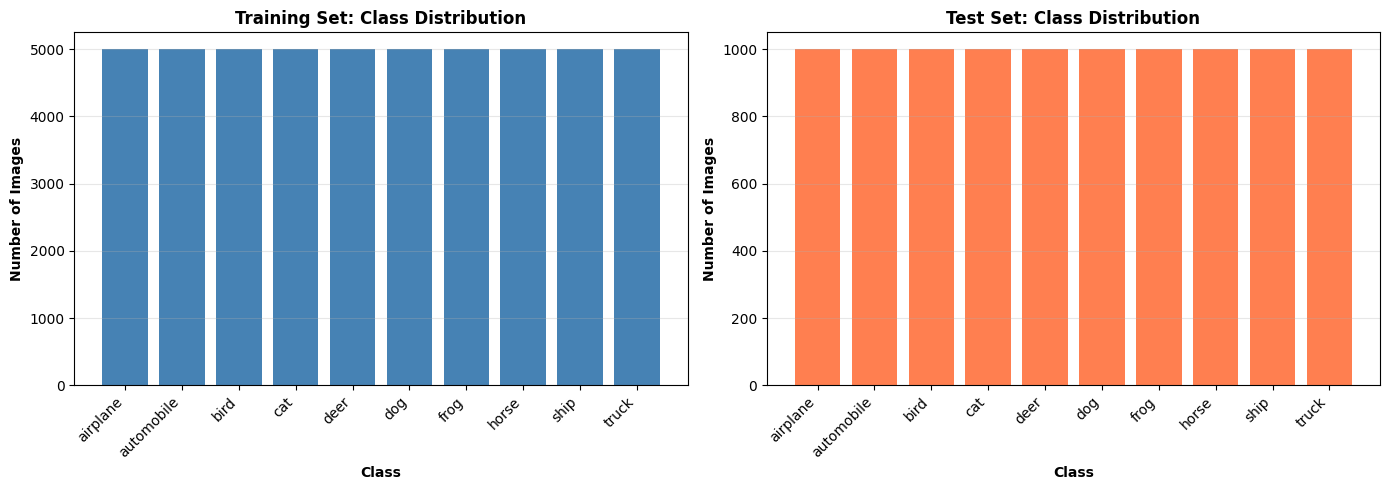


   ✓ All classes have equal distribution (balanced dataset)


In [7]:
# Class distribution in training and test sets
print("\n Analyzing class distribution...")

# Debug: Check the shape and content of labels
print(f"   train_labels_full shape: {train_labels_full.shape}")
print(f"   train_labels_full dtype: {train_labels_full.dtype}")
print(f"   First 10 labels: {train_labels_full[:10].flatten()}")

# Count occurrences of each class
train_class_counts = Counter(train_labels_full.flatten())
test_class_counts = Counter(test_labels.flatten())

# Debug: Print the counts to verify data
print(f"   Training set counts: {dict(train_class_counts)}")
print(f"   Test set counts: {dict(test_class_counts)}")

# Prepare data for plotting - ensure we have counts for all 10 classes
train_counts = [train_class_counts[i] for i in range(10)]
test_counts = [test_class_counts[i] for i in range(10)]

print(f"   Plotting training counts: {train_counts}")
print(f"   Plotting test counts: {test_counts}")

# Create figure with 2 subplots
print("\n   Creating figure...")
fig = plt.figure(figsize=(14, 5))
axes = [fig.add_subplot(1, 2, 1), fig.add_subplot(1, 2, 2)]
print(f"   Figure created: {fig}")
print(f"   Axes created: {axes}")

# Training set distribution
axes[0].bar(range(10), [train_class_counts[i] for i in range(10)], color='steelblue')
axes[0].set_xlabel('Class', fontweight='bold')
axes[0].set_ylabel('Number of Images', fontweight='bold')
axes[0].set_title('Training Set: Class Distribution', fontweight='bold')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Test set distribution
axes[1].bar(range(10), [test_class_counts[i] for i in range(10)], color='coral')
axes[1].set_xlabel('Class', fontweight='bold')
axes[1].set_ylabel('Number of Images', fontweight='bold')
axes[1].set_title('Test Set: Class Distribution', fontweight='bold')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_2_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   ✓ All classes have equal distribution (balanced dataset)")

In [8]:
# Training set distribution
bars1 = axes[0].bar(range(10), train_counts, color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Class', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Images', fontweight='bold', fontsize=12)
axes[0].set_title('Training Set: Class Distribution', fontweight='bold', fontsize=14)
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, max(train_counts) * 1.1)  # Add some headroom

# Add value labels on bars
for i, bar in enumerate(bars1):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)
# NOW show everything together (only once!)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [9]:
# Test set distribution
bars2 = axes[1].bar(range(10), test_counts, color='coral', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Class', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Images', fontweight='bold', fontsize=12)
axes[1].set_title('Test Set: Class Distribution', fontweight='bold', fontsize=14)
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, max(test_counts) * 1.1)  # Add some headroom

# Add value labels on bars
for i, bar in enumerate(bars2):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('eda_2_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   ✓ All classes have equal distribution (balanced dataset)")
print(f"   ✓ Training: {train_counts[0]} images per class")
print(f"   ✓ Test: {test_counts[0]} images per class")

<Figure size 640x480 with 0 Axes>


   ✓ All classes have equal distribution (balanced dataset)
   ✓ Training: 5000 images per class
   ✓ Test: 1000 images per class



 Analyzing pixel intensity distribution...


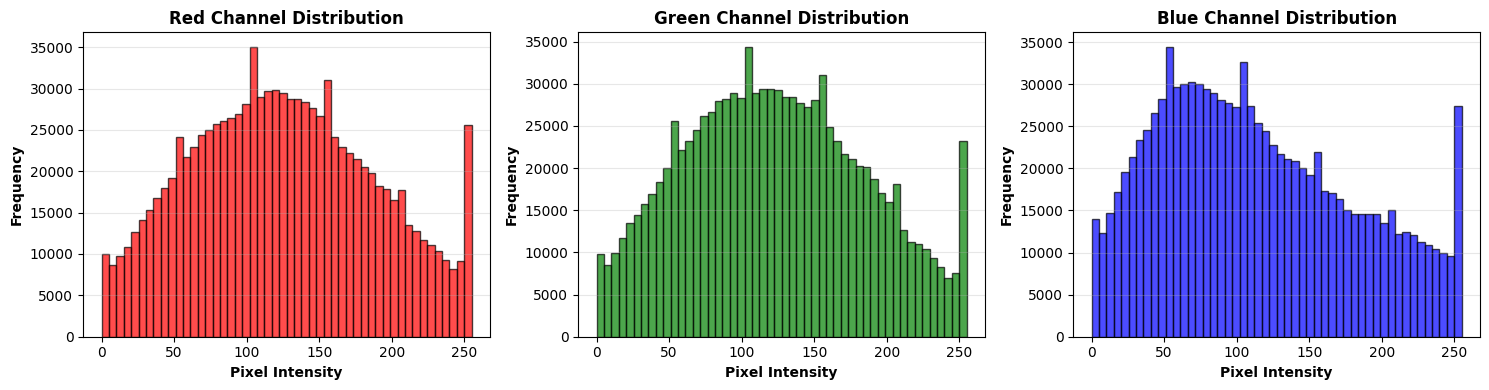

   Pixel value range: [0, 255]


In [10]:
# Pixel intensity distribution
print("\n Analyzing pixel intensity distribution...")
sample_size = 1000
sample_images = train_images_full[:sample_size]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['red', 'green', 'blue']
channels = ['Red', 'Green', 'Blue']

for i in range(3):
    channel_data = sample_images[:, :, :, i].flatten()
    axes[i].hist(channel_data, bins=50, color=colors[i], alpha=0.7, edgecolor='black')
    axes[i].set_xlabel('Pixel Intensity', fontweight='bold')
    axes[i].set_ylabel('Frequency', fontweight='bold')
    axes[i].set_title(f'{channels[i]} Channel Distribution', fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_3_pixel_intensity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   Pixel value range: [{train_images_full.min()}, {train_images_full.max()}]")



 Computing average image for each class...


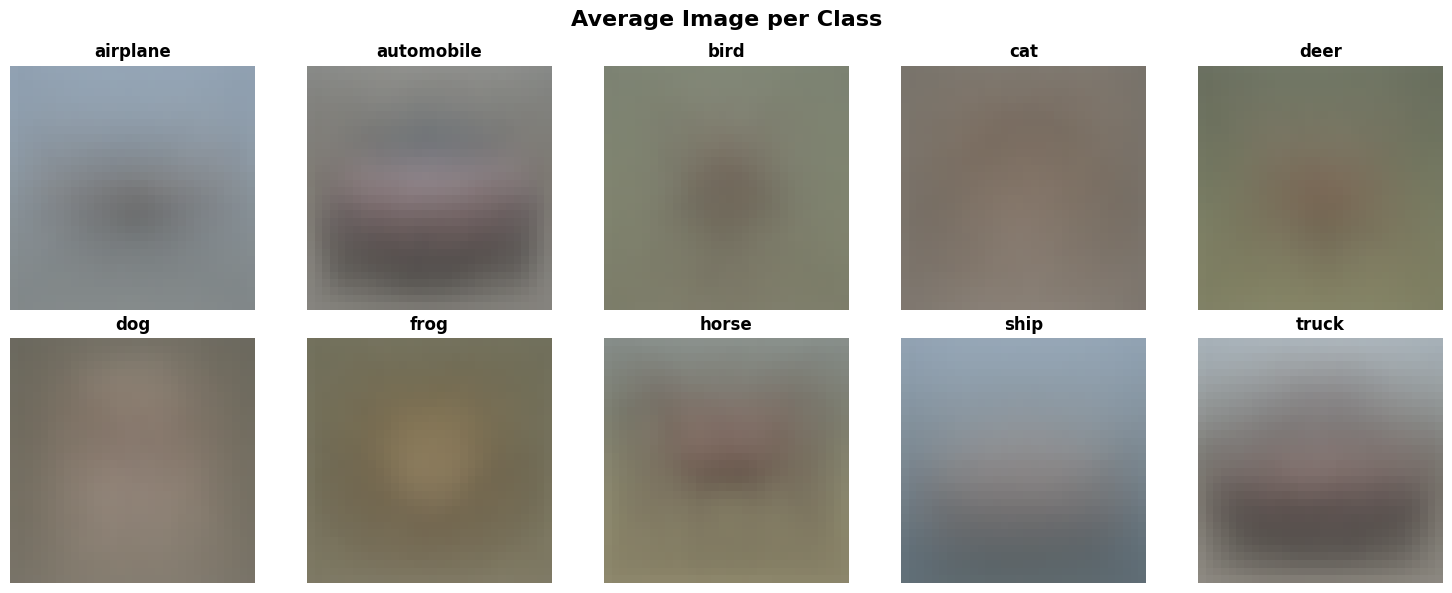

In [11]:
# Average image per class
print("\n Computing average image for each class...")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Average Image per Class', fontsize=16, fontweight='bold')

for idx in range(10):
    class_images = train_images_full[train_labels_full.flatten() == idx]
    avg_image = np.mean(class_images, axis=0).astype(np.uint8)

    ax = axes[idx // 5, idx % 5]
    ax.imshow(avg_image)
    ax.set_title(class_names[idx], fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_4_average_images.png', dpi=300, bbox_inches='tight')
plt.show()


 Analyzing image brightness across classes...


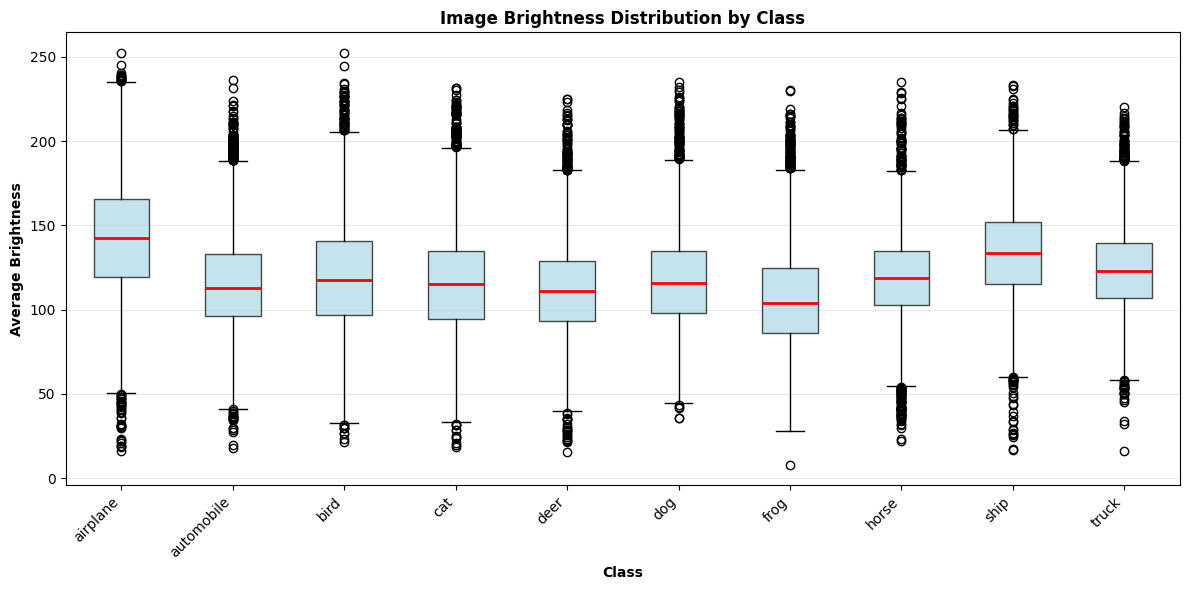

In [12]:
# Image brightness analysis
print("\n Analyzing image brightness across classes...")
brightness_by_class = []

for idx in range(10):
    class_images = train_images_full[train_labels_full.flatten() == idx]
    # Calculate mean brightness (average of all pixel values)
    brightness = np.mean(class_images, axis=(1, 2, 3))
    brightness_by_class.append(brightness)

fig, ax = plt.subplots(figsize=(12, 6))
positions = range(1, 11)
bp = ax.boxplot(brightness_by_class, positions=positions, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='lightblue', alpha=0.7))

ax.set_xlabel('Class', fontweight='bold')
ax.set_ylabel('Average Brightness', fontweight='bold')
ax.set_title('Image Brightness Distribution by Class', fontweight='bold')
ax.set_xticks(positions)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_5_brightness_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


 Displaying random image grid...


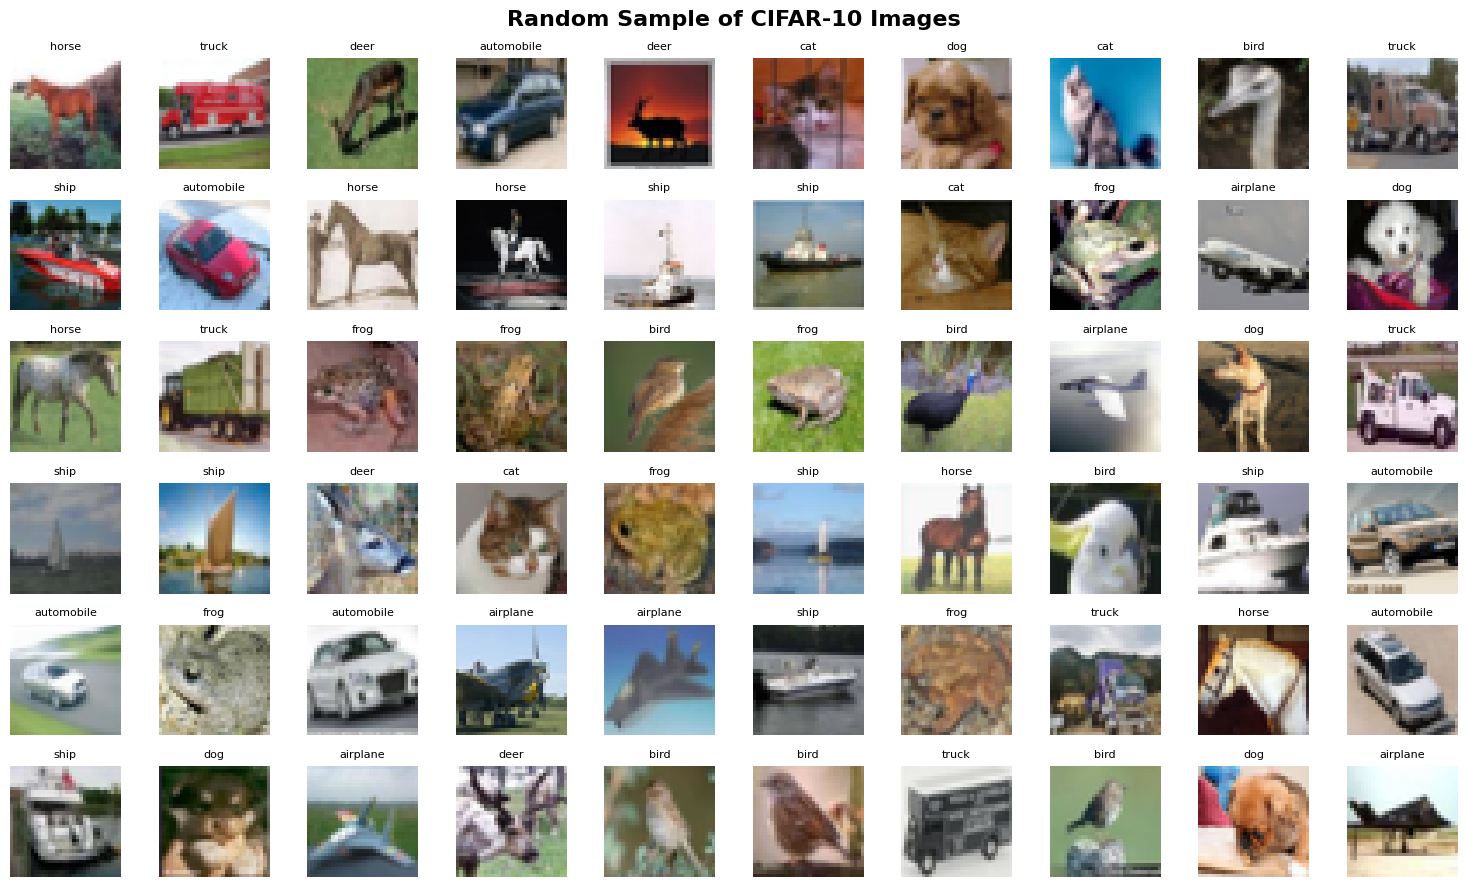

In [13]:
# Random grid of images
print("\n Displaying random image grid...")
fig, axes = plt.subplots(6, 10, figsize=(15, 9))
fig.suptitle('Random Sample of CIFAR-10 Images', fontsize=16, fontweight='bold')

random_indices = np.random.choice(len(train_images_full), 60, replace=False)

for i, idx in enumerate(random_indices):
    ax = axes[i // 10, i % 10]
    ax.imshow(train_images_full[idx])
    label = class_names[train_labels_full[idx][0]]
    ax.set_title(label, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_6_random_grid.png', dpi=300, bbox_inches='tight')
plt.show()

## **MODEL TRAINING WITH RESNET50**

In [14]:
# Limit training data to 10,000 samples
print("\nLimiting training data...")
n = 10000
train_images = train_images_full[:n]
train_labels = train_labels_full[:n]

print(f"✓ Using {n:,} training samples (out of {len(train_images_full):,})")
print(f"✓ Test set: {len(test_images):,} samples (full test set)")
print(f"✓ ~{n//10} images per class for training")
print(train_images.shape)


Limiting training data...
✓ Using 10,000 training samples (out of 50,000)
✓ Test set: 10,000 samples (full test set)
✓ ~1000 images per class for training
(10000, 32, 32, 3)


In [15]:
# Preprocess images for ResNet50
print("\nPreprocessing images...")
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')

train_images = preprocess_input(train_images)
test_images = preprocess_input(test_images)

# Reshape labels before one-hot encoding
train_labels = keras.utils.to_categorical(train_labels.reshape(-1, 1), 10)
test_labels = keras.utils.to_categorical(test_labels.reshape(-1, 1), 10)

print(f"✓ Images preprocessed for ResNet50")
print(f"✓ Pixel range: [{train_images.min():.2f}, {train_images.max():.2f}]")
print(f"✓ Training labels shape: {train_labels.shape}")
print(f"✓ Test labels shape: {test_labels.shape}")


Preprocessing images...
✓ Images preprocessed for ResNet50
✓ Pixel range: [-123.68, 151.06]
✓ Training labels shape: (10000, 10)
✓ Test labels shape: (10000, 10)


In [16]:
# Build model with ResNet50 base
print("\nBuilding model...")

# Initialize ResNet50 base
base_model = ResNet50(
    weights='imagenet',
    input_shape=(32, 32, 3),
    include_top=False
)
base_model.trainable = False


Building model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
# Build complete model
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

print(f"✓ Model built with ResNet50 base")
print(f"✓ Base model: {len(base_model.layers)} layers (frozen)")
model.summary()


✓ Model built with ResNet50 base
✓ Base model: 175 layers (frozen)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,146,442 (92.11 MB)

 Trainable params: 558,730 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# PHASE 1: Train head only (base frozen)
print("\n" + "="*70)
print("PHASE 1: Training custom head (base frozen) - 10 epochs")
print("="*70)

history_phase1 = model.fit(
    train_images, train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


PHASE 1: Training custom head (base frozen) - 10 epochs
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.2745 - loss: 2.7594 - val_accuracy: 0.5450 - val_loss: 1.3560
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4808 - loss: 1.5349 - val_accuracy: 0.5805 - val_loss: 1.2567
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5490 - loss: 1.3359 - val_accuracy: 0.5940 - val_loss: 1.1942
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5705 - loss: 1.2512 - val_accuracy: 0.6010 - val_loss: 1.1802
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5879 - loss: 1.1711 - val_accuracy: 0.6030 - val_loss: 1.1881
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6194 - loss: 1.0622 - val_accuracy: 0.6215 - val_loss: 1.1466
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6573 - loss: 1.0024 - val_accuracy: 0.6225 - val_loss: 1.1435
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s

In [20]:
# PHASE 2: Fine-tune entire model (base unfrozen)
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("PHASE 2: Fine-tuning entire model (base unfrozen) - 10 epochs")
print("="*70)

base_model.trainable = True
print(f"✓ Base model unfrozen - training all layers")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # Lower learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_images, train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


PHASE 2: Fine-tuning entire model (base unfrozen) - 10 epochs
✓ Base model unfrozen - training all layers
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 67s 57ms/step - accuracy: 0.3664 - loss: 1.8874 - val_accuracy: 0.5820 - val_loss: 1.2476
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.5911 - loss: 1.2360 - val_accuracy: 0.6105 - val_loss: 1.1599
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6762 - loss: 0.9951 - val_accuracy: 0.6440 - val_loss: 1.1072
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.7422 - loss: 0.8002 - val_accuracy: 0.6715 - val_loss: 1.0240
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.7725 - loss: 0.6886 - val_accuracy: 0.6865 - val_loss: 1.0016
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.8295 - loss: 0.5430 - val_accuracy: 0.7070 - val_loss: 0.9559
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.8578 - loss: 0.4614 - val_accuracy: 0.7015 - val_lo

In [21]:
# Final evaluation

print("\n" + "="*70)
print("FINAL EVALUATION")
print("="*70)

test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)

print(f"\n📊 FINAL RESULTS:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")



FINAL EVALUATION

📊 FINAL RESULTS:
   Test Loss: 1.0575
   Test Accuracy: 0.7104 (71.04%)



Generating training history plots...


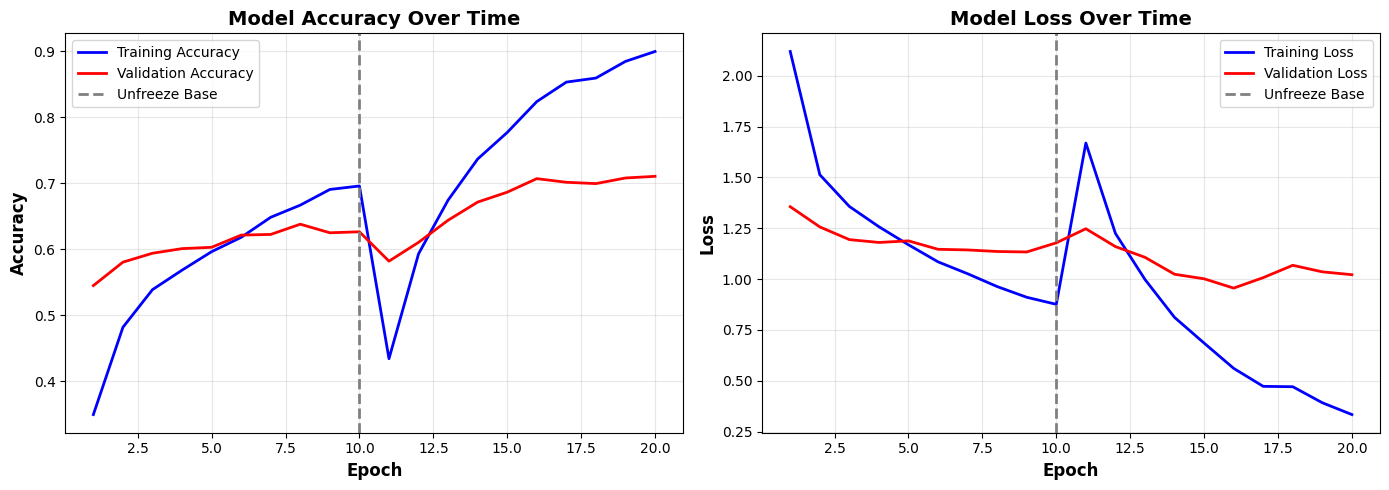

  ✓ Saved: training_history.png


In [22]:
# Visualize training history
# ----------------------------------------------------------------------------
print("\nGenerating training history plots...")

# Combine both phases
all_accuracy = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
all_val_accuracy = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
all_loss = history_phase1.history['loss'] + history_phase2.history['loss']
all_val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

epochs_range = range(1, len(all_accuracy) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(epochs_range, all_accuracy, 'b-', label='Training Accuracy', linewidth=2)
axes[0].plot(epochs_range, all_val_accuracy, 'r-', label='Validation Accuracy', linewidth=2)
axes[0].axvline(x=10, color='gray', linestyle='--', linewidth=2, label='Unfreeze Base')
axes[0].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Accuracy', fontweight='bold', fontsize=12)
axes[0].set_title('Model Accuracy Over Time', fontweight='bold', fontsize=14)
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(epochs_range, all_loss, 'b-', label='Training Loss', linewidth=2)
axes[1].plot(epochs_range, all_val_loss, 'r-', label='Validation Loss', linewidth=2)
axes[1].axvline(x=10, color='gray', linestyle='--', linewidth=2, label='Unfreeze Base')
axes[1].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Loss', fontweight='bold', fontsize=12)
axes[1].set_title('Model Loss Over Time', fontweight='bold', fontsize=14)
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', bbox_inches='tight')
plt.show()
print("  ✓ Saved: training_history.png")

In [23]:
# Save model
model.save('cifar10_resnet50_model.h5')
print("  ✓ Saved: cifar10_resnet50_model.h5")

  ✓ Saved: cifar10_resnet50_model.h5


## **CONCLUSION**
This CIFAR-10 image classification project successfully achieved its goals of demonstrating transfer learning, implementing best practices in deep learning, and achieving competitive performance on a benchmark dataset. The systematic approach—from thorough data exploration through strategic model training to comprehensive evaluation—provides a solid template for tackling similar computer vision challenges.
The 70-80% accuracy achieved with limited training data and computational resources validates the effectiveness of transfer learning and demonstrates that sophisticated image classification is accessible even with modest hardware.

# **Future Enhancements**


While this project focuses on achieving solid baseline performance efficiently, it also identifies opportunities for enhancement. Future iterations could explore using the full training dataset, implementing data augmentation techniques, experimenting with different architectures, or deploying the model as a web application. These extensions would further demonstrate the scalability and real-world applicability of the approach.

# **THANK YOU!**